In [1]:
# Data Wrangling
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Date Functionality
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

# Statistical analysis
from scipy.stats import ttest_ind


# Remove Warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
data_transaction = pd.read_excel("QVI_transaction_data.xlsx")
data_transaction

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Company SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


**To check missing Data**

In [10]:
data_transaction.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0


No Missing Data in the datasets.

In [11]:
# Look for duplicated TXN_ID

data_transaction[data_transaction.duplicated(['TXN_ID'])].head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
42,2019-05-20,55,55073,48887,113,Twisties Chicken270g,1,4.6
377,2019-01-10,7,7364,7739,20,Doritos Cheese Supreme 330g,2,11.4
419,2018-10-18,12,12301,10982,93,Doritos Corn Chip Southern Chicken 150g,2,7.8
476,2018-09-08,16,16427,14546,81,Pringles Original Crisps 134g,1,3.7
511,2018-08-03,19,19272,16683,31,Infzns Crn Crnchers Tangy Gcamole 110g,2,7.6


In [22]:
# Select the first duplicated TXN_ID

data_transaction.loc[data_transaction['TXN_ID'] == 48887, :]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
41,2019-05-20,55,55073,48887,4,Dorito Corn Chp Supreme 380g,1,3.25
42,2019-05-20,55,55073,48887,113,Twisties Chicken270g,1,4.60


**Categorise Numeric & categorical Data**

In [23]:
data_transaction_numerics_only = data_transaction.select_dtypes(include=np.number)
data_transaction_cat = set(data_transaction.columns) - set(data_transaction_numerics_only)

In [24]:
print("Numeric Columns:\n",list(data_transaction_numerics_only))
print("Categorical Columns:\n",list(data_transaction_cat))

Numeric Columns:
 ['STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_QTY', 'TOT_SALES']
Categorical Columns:
 ['DATE', 'PROD_NAME']


**To Check Outliers and Treat them**

In [25]:
def remove_outlier_IQR(df):
    Q1=df.quantile(0.25)
    Q3=df.quantile(0.75)
    IQR=Q3-Q1
    df_final=df[~((df<(Q1-1.5*IQR)) | (df>(Q3+1.5*IQR)))]
    return df_final

Text(0, 0.5, 'Total Sales)')

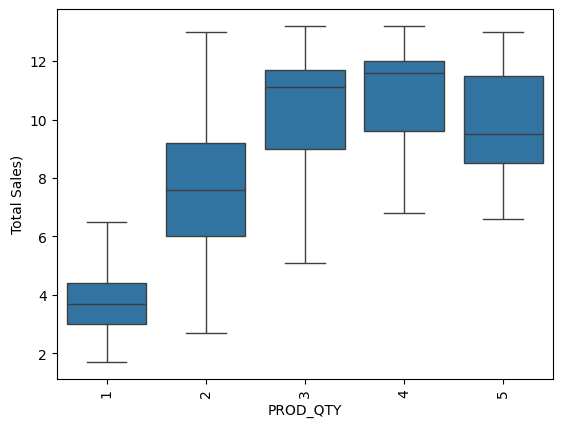

In [26]:
df_outlier_removed=remove_outlier_IQR(data_transaction.TOT_SALES)
df_outlier_removed=pd.DataFrame(df_outlier_removed)
ind_diff=data_transaction.index.difference(df_outlier_removed.index)

for i in range(0, len(ind_diff),1):
    df_final=data_transaction.drop([ind_diff[i]])
    data_transaction =df_final

sns.boxplot(y='TOT_SALES', x='PROD_QTY',data=data_transaction)
plt.xticks(rotation=90)
plt.ylabel('Total Sales)')

In [27]:
print("Shape of dataset after treating outliers:",data_transaction.shape)

Shape of dataset after treating outliers: (246073, 8)


*Comparing the two boxplots, it can be seen that the outliers were removed.*

In [28]:
data_transaction['PROD_NAME'].value_counts()

,count
PROD_NAME,
Kettle Mozzarella Basil & Pesto 175g,3280
Kettle Tortilla ChpsHny&Jlpno Chili 150g,3279
Tyrrells Crisps Ched & Chives 165g,3264
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,3260
Cobs Popd Sea Salt Chips 110g,3259
...,...
Red Rock Deli Chikn&Garlic Aioli 150g,1427
French Fries Potato Chips 175g,1418
NCC Sour Cream & Garden Chives 175g,1416


In [29]:
# The customer only wants insights on chips category, hence, we eliminate all the other products.
data_transaction = data_transaction[data_transaction["PROD_NAME"].str.contains("Salsa")==False]
data_transaction

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Company SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [30]:
data_transaction['PROD_NAME'].value_counts()

,count
PROD_NAME,
Kettle Mozzarella Basil & Pesto 175g,3280
Kettle Tortilla ChpsHny&Jlpno Chili 150g,3279
Tyrrells Crisps Ched & Chives 165g,3264
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,3260
Cobs Popd Sea Salt Chips 110g,3259
...,...
Red Rock Deli Chikn&Garlic Aioli 150g,1427
French Fries Potato Chips 175g,1418
NCC Sour Cream & Garden Chives 175g,1416


In [31]:
# Extracting pack size from the Product
import re
def find_number(text):
    num = re.findall(r'[0-9]+',text)
    return " ".join(num)
data_transaction['pack_size']=data_transaction['PROD_NAME'].apply(lambda x: find_number(x))
data_transaction

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,pack_size
0,2018-10-17,1,1000,1,5,Natural Chip Company SeaSalt175g,2,6.0,175
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210
...,...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150


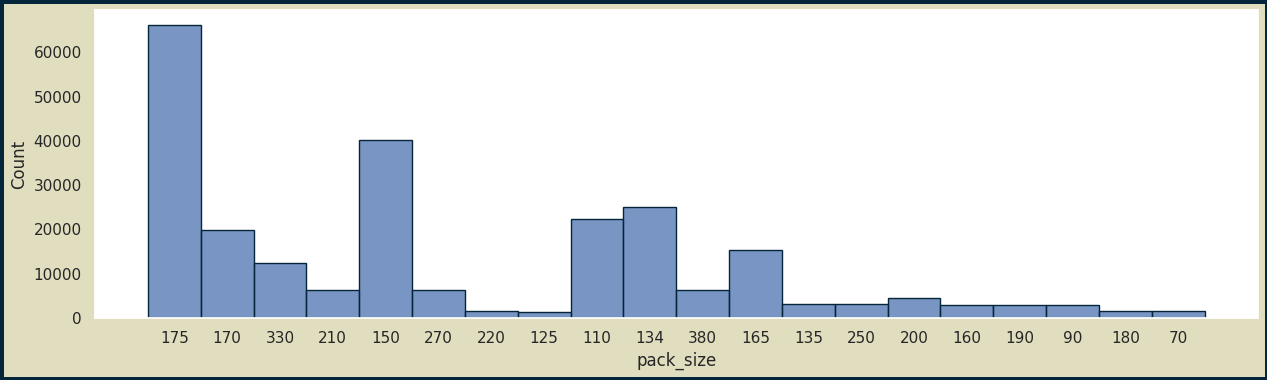

In [33]:
# Histogram showing the number of transactions by pack size

fig = plt.figure(figsize = (15,4), linewidth=5, edgecolor="#04253a", facecolor = '#e1ddbf')

sns.set(rc = {'figure.figsize':(15,4)})
ax = sns.histplot(data=data_transaction, x="pack_size",  edgecolor="#04253a")

ax.set_facecolor("#ffffff")

*175g is the highest selling pack size for the chips followed by 150g.*

In [34]:
# Create column for brand names
data_transaction['Brand Name'] = data_transaction['PROD_NAME'].str.split(' ').str[0]

In [35]:
# Check for any duplication or similar brands
data_transaction['Brand Name'].value_counts()

,count
Brand Name,
Kettle,41108
Smiths,27321
Pringles,25012
Doritos,21975
Thins,14049
RRD,11874
Infuzions,11035
WW,10320
Cobs,9669


*Some Brands are similar like RRD and Red Rock Deli , WW and Woolworths,NCC and Natural Chip Company etc.Let us combine them together as they are a single unit.*

In [36]:
data_transaction['Brand Name'] = data_transaction['Brand Name'].str.replace('Red','RRD')
data_transaction['Brand Name'] = data_transaction['Brand Name'].str.replace('Woolworths','WW')
data_transaction['Brand Name'] = data_transaction['Brand Name'].str.replace('INFUZIONS','INFZNS')
data_transaction['Brand Name'] = data_transaction['Brand Name'].str.replace('SMITHS','SMITH')
data_transaction['Brand Name'] = data_transaction['Brand Name'].str.replace('SUNBITES','SNBTS')
data_transaction['Brand Name'] = data_transaction['Brand Name'].str.replace('DORITOS','DORITO')
data_transaction['Brand Name'] = data_transaction['Brand Name'].str.replace('GRNWVES','GRAIN')

In [37]:
data_transaction['Brand Name'].value_counts()

,count
Brand Name,
Kettle,41108
Smiths,27321
Pringles,25012
Doritos,21975
RRD,16289
Thins,14049
WW,11836
Infuzions,11035
Cobs,9669


*Combined the similar brands.*

**Examining customer data**

In [38]:
data_customer = pd.read_csv("QVI_purchase_behaviour.csv")
data_customer

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


**To check for null Values in the data.**

In [39]:
data_customer.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


**Categorise Numeric and Categorical Data**

In [41]:
data_customer_numerics_only = data_customer.select_dtypes(include=np.number)
data_customer_cat = set(data_customer.columns) - set(data_customer_numerics_only)

In [42]:
print("Numeric Columns:\n",list(data_customer_numerics_only))
print("Categorical Columns:\n",data_customer_cat)

Numeric Columns:
 ['LYLTY_CARD_NBR']
Categorical Columns:
 {'LIFESTAGE', 'PREMIUM_CUSTOMER'}


In [43]:
# Merging the two dataframes
df4 = pd.merge(data_transaction,data_customer)
df4

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,pack_size,Brand Name,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Company SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,Grain,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...
246068,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175,Kettle,YOUNG SINGLES/COUPLES,Premium
246069,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175,Tostitos,YOUNG SINGLES/COUPLES,Premium
246070,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170,Doritos,YOUNG SINGLES/COUPLES,Premium
246071,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150,Doritos,YOUNG SINGLES/COUPLES,Premium


In [44]:
# To check if some customers were not matched on by checking for nulls.
df4.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
pack_size,0
Brand Name,0


In [45]:
pd.date_range(start = '2018-07-01', end = '2019-06-30').difference(df4['DATE'])

DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')

*We have a missing date on Christmas Day. This makes sense because most retail stores are closed that day.*

In [46]:
# Create a new dataframe which contains the total sale for each date

df5 = pd.pivot_table(df4, values = 'TOT_SALES', index = 'DATE', aggfunc = 'sum')
df5.head()

,TOT_SALES
DATE,
2018-07-01,4920.1
2018-07-02,4877.0
2018-07-03,4954.7
2018-07-04,4968.1
2018-07-05,4682.0


In [47]:
df6 = pd.DataFrame(index = pd.date_range(start = '2018-07-01', end = '2019-06-30'))
df6['TOT_SALES'] = 0
len(df6)

365

In [48]:
z = df5 + df6
z.fillna(0, inplace = True)

In [49]:
z.index.name = 'Date'
z.rename(columns = {'TOT_SALES': 'Total Sales'}, inplace = True)
z.head()

,Total Sales
Date,
2018-07-01,4920.1
2018-07-02,4877.0
2018-07-03,4954.7
2018-07-04,4968.1
2018-07-05,4682.0


Text(0, 0.5, 'Total Sales')

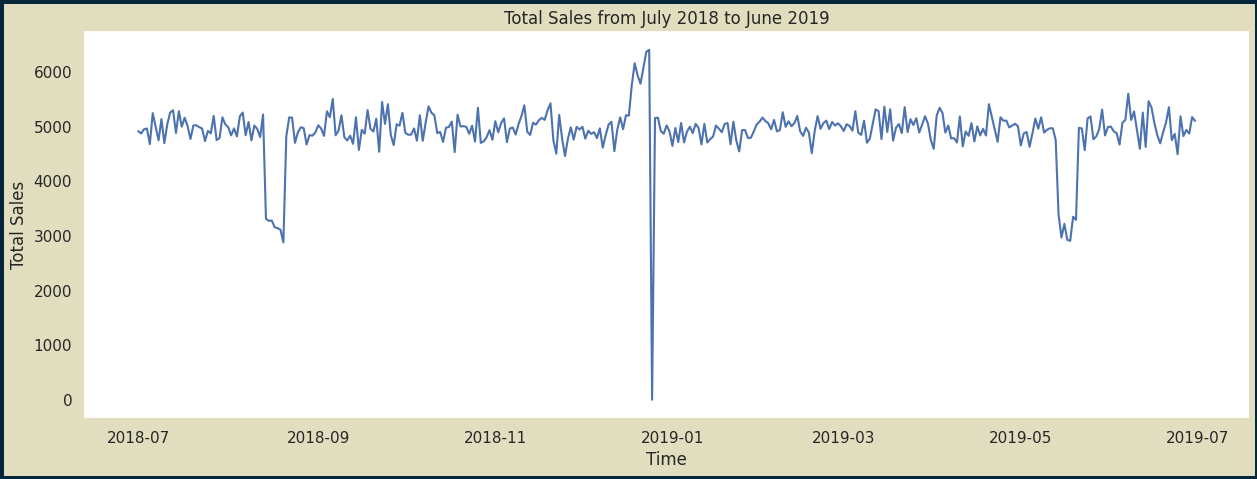

In [50]:
timeline = z.index
graph = z['Total Sales']



fig, ax = plt.subplots(figsize = (15, 5), linewidth=5, edgecolor="#04253a", facecolor = '#e1ddbf')

ax.plot(timeline, graph)

ax.set_facecolor("#ffffff")

date_form = DateFormatter("%Y-%m")
ax.xaxis.set_major_formatter(date_form)
plt.title('Total Sales from July 2018 to June 2019')
plt.xlabel('Time')
plt.ylabel('Total Sales')

*We can see that sales spike up during the December month and zero sale on Christmas Day.*

In [51]:
# Let's look at the December month only

z_december = z[(z.index < "2019-01-01") & (z.index > "2018-11-30")]
z_december.head()

,Total Sales
Date,
2018-12-01,5000.9
2018-12-02,4781.1
2018-12-03,4927.0
2018-12-04,4869.4
2018-12-05,4900.5


Text(0.5, 1.0, 'Total Sales in December')

<Figure size 1500x500 with 0 Axes>

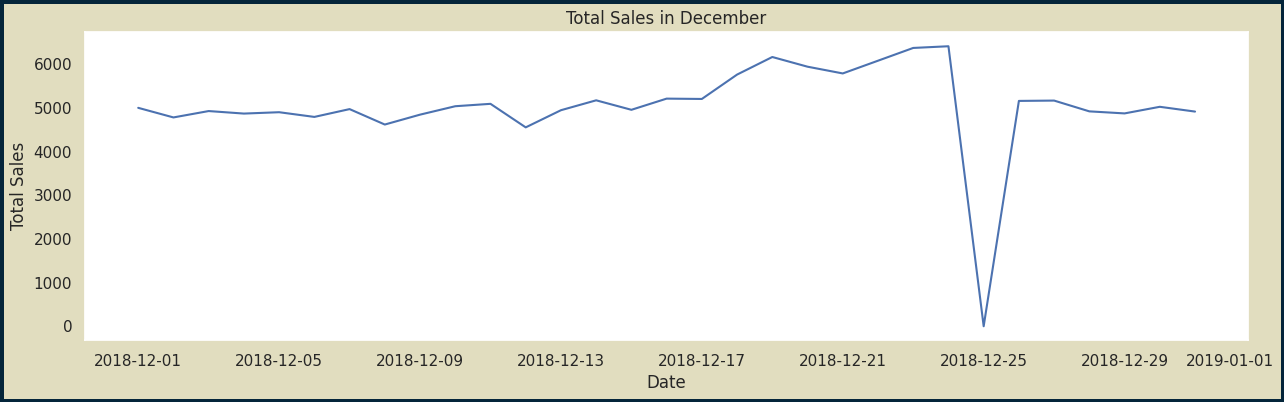

In [52]:
plt.figure(figsize = (15, 5))
fig = plt.figure(linewidth=5, edgecolor="#04253a", facecolor = '#e1ddbf')

ax = sns.lineplot(data= z_december, x= 'Date', y = 'Total Sales')
ax.set_facecolor("#ffffff")

plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Total Sales in December')

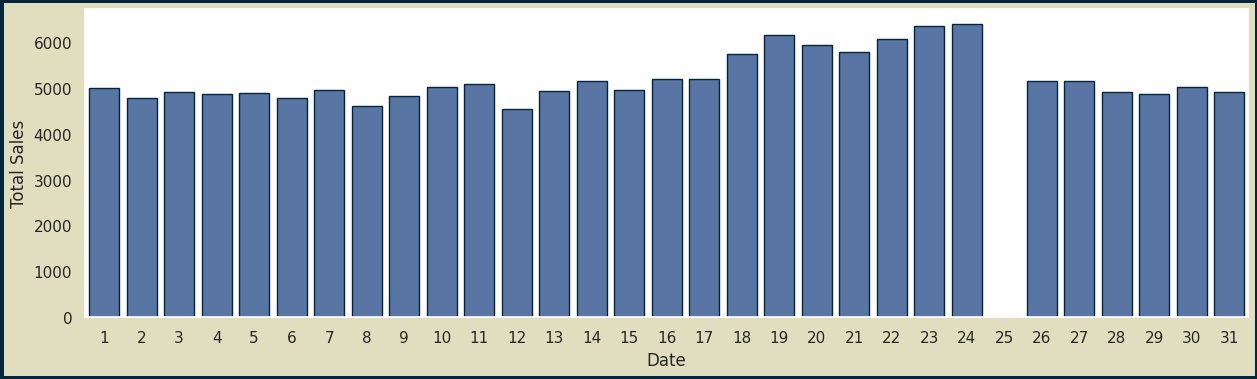

In [53]:
# Reset index

z_december.reset_index(drop = True, inplace = True)
z_december.head()

z_december['Date'] = z_december.index + 1
z_december.head()

fig = plt.figure(linewidth=5, edgecolor="#04253a", facecolor = '#e1ddbf')

ax = sns.barplot(x = 'Date', y ='Total Sales', data = z_december,  edgecolor="#04253a")

ax.set_facecolor("#ffffff")

*We can see that the Sales have increased till the day before Christmas i.e. 2018-12-24 and there are no transaction records on 25th of December because of the Holiday and also the sales went down after Christmas.*

# Data analysis on customer segments

**1. Who spends the most on chips i.e. describing customers by lifestage and premimum category?**

In [54]:
df4

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,pack_size,Brand Name,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Company SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,Grain,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...
246068,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175,Kettle,YOUNG SINGLES/COUPLES,Premium
246069,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175,Tostitos,YOUNG SINGLES/COUPLES,Premium
246070,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170,Doritos,YOUNG SINGLES/COUPLES,Premium
246071,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150,Doritos,YOUNG SINGLES/COUPLES,Premium


In [55]:
df4['LIFESTAGE'].value_counts()

,count
LIFESTAGE,
OLDER SINGLES/COUPLES,50645
RETIREES,46318
OLDER FAMILIES,45015
YOUNG FAMILIES,40372
YOUNG SINGLES/COUPLES,33901
MIDAGE SINGLES/COUPLES,23334
NEW FAMILIES,6488


In [56]:
df4['PREMIUM_CUSTOMER'].value_counts()

,count
PREMIUM_CUSTOMER,
Mainstream,94787
Budget,86522
Premium,64764


<Figure size 1500x400 with 0 Axes>

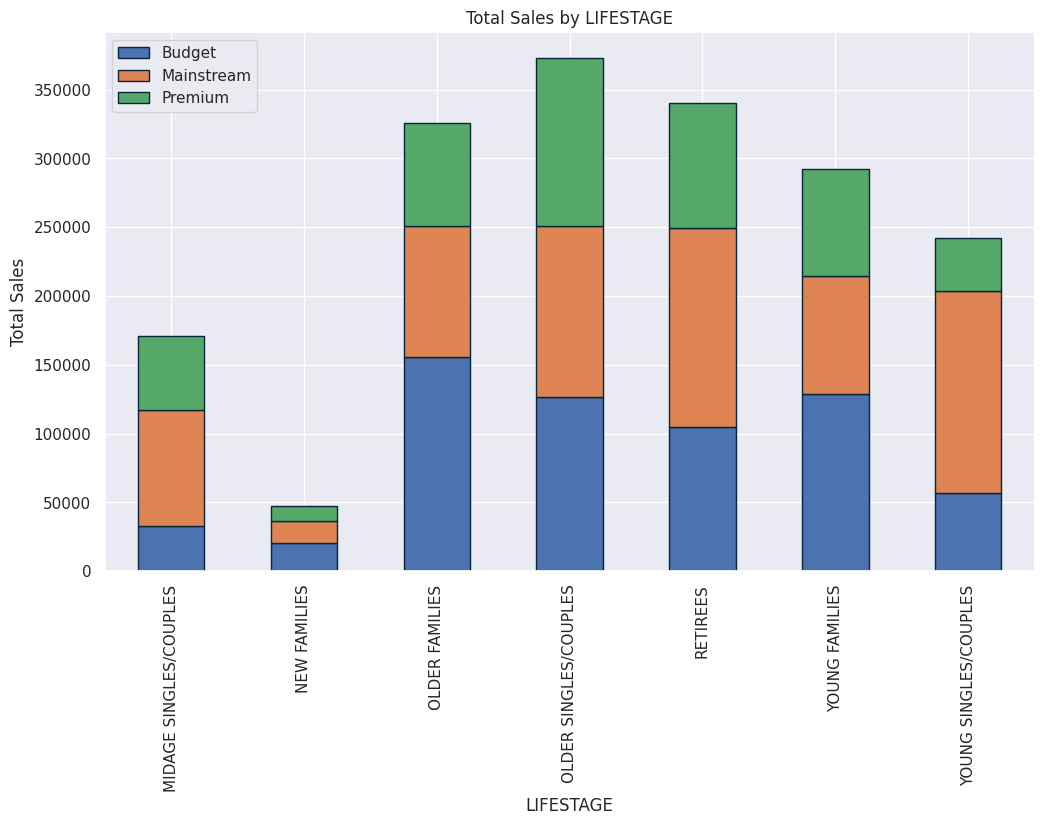

In [57]:
df8 = pd.DataFrame(df4.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).TOT_SALES.sum())

fig = plt.figure(linewidth=5, edgecolor="#04253a", facecolor = '#e1ddbf')

df8.unstack().plot(kind = 'bar', stacked = True, figsize = (12, 7), title = 'Total Sales by LIFESTAGE' , edgecolor="#04253a")

plt.ylabel('Total Sales')
plt.legend(['Budget', 'Mainstream', 'Premium'], loc = 2)

*The sales are high for Budget-Older Families, Mainstream-young singles/couples, Mainstream - retirees and premium - Older Single/Couples.*

**2. How many customers are there in each segment?**

In [58]:
df9 = pd.DataFrame(df4.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE']).LYLTY_CARD_NBR.nunique())
df9.rename(columns = {'LYLTY_CARD_NBR': 'Number of Customers'}, inplace = True)

In [60]:
df9 = df9.sort_values(by = 'Number of Customers', ascending = False).head(10)

In [61]:
df9

Number of Customers
PREMIUM_CUSTOMER LIFESTAGE                                 
Mainstream       YOUNG SINGLES/COUPLES                 7902
                 RETIREES                              6356
                 OLDER SINGLES/COUPLES                 4852
Budget           OLDER SINGLES/COUPLES                 4845
Premium          OLDER SINGLES/COUPLES                 4681
Budget           OLDER FAMILIES                        4606
                 RETIREES                              4381
                 YOUNG FAMILIES                        3949
Premium          RETIREES                              3811
Budget           YOUNG SINGLES/COUPLES                 3642

In [62]:
df9 = pd.DataFrame(df4.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).LYLTY_CARD_NBR.nunique())

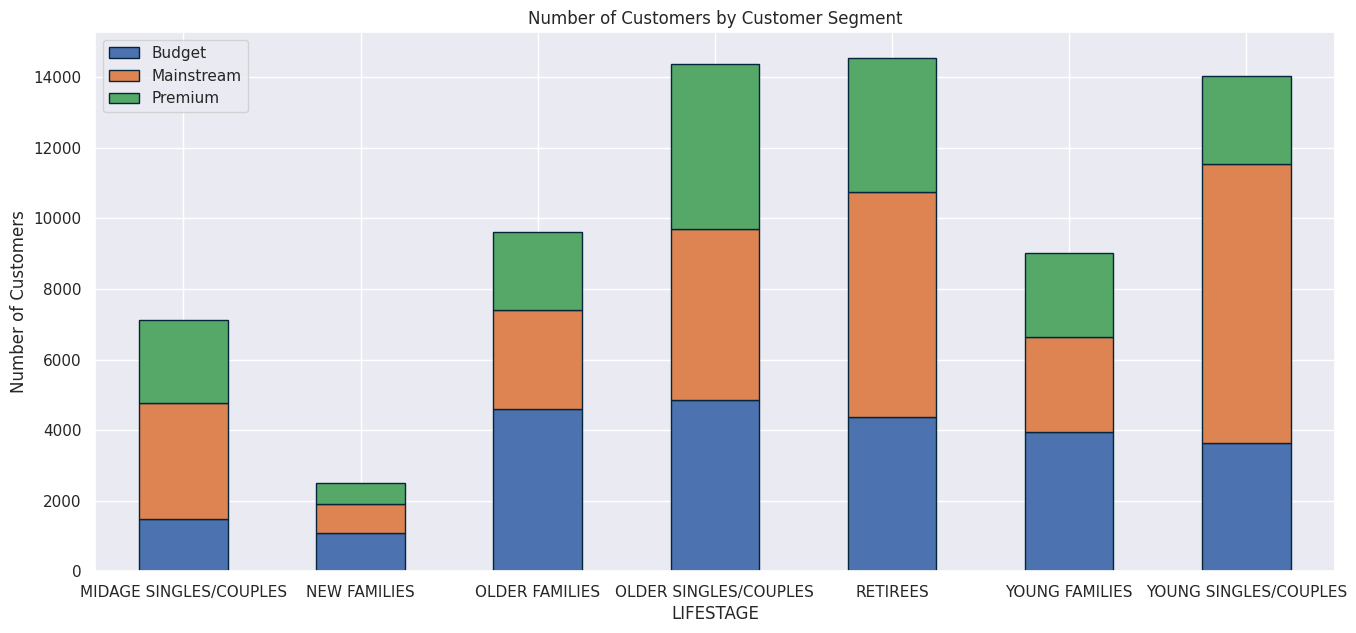

In [63]:
df9.unstack().plot(kind='bar', stacked = True , rot=0 , figsize = (16, 7), title = 'Number of Customers by Customer Segment',  edgecolor="#04253a")
plt.ylabel('Number of Customers')
plt.legend(['Budget', 'Mainstream', 'Premium'], loc = 2)

***There are more mainstream young singles/couples and retirees. This contributes to to more chips sales in these segments however this is not the major driver for the budget older families segment.***

**3. How many chips are bought per customer by segment?**

In [65]:
df10 = df4.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE']).PROD_QTY.sum() / df4.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE']).LYLTY_CARD_NBR.nunique()

df10 = pd.DataFrame(df10, columns = ['Average Unit per Customer'])

In [66]:
df10.sort_values(by = 'Average Unit per Customer', ascending = False).head()

,,Average Unit per Customer
PREMIUM_CUSTOMER,LIFESTAGE,
Mainstream,OLDER FAMILIES,9.177188
Budget,OLDER FAMILIES,9.030178
Premium,OLDER FAMILIES,9.002242
Budget,YOUNG FAMILIES,8.674095
Premium,YOUNG FAMILIES,8.667362


In [67]:
df10 = pd.DataFrame(df4.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).PROD_QTY.sum() / df4.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).LYLTY_CARD_NBR.nunique())

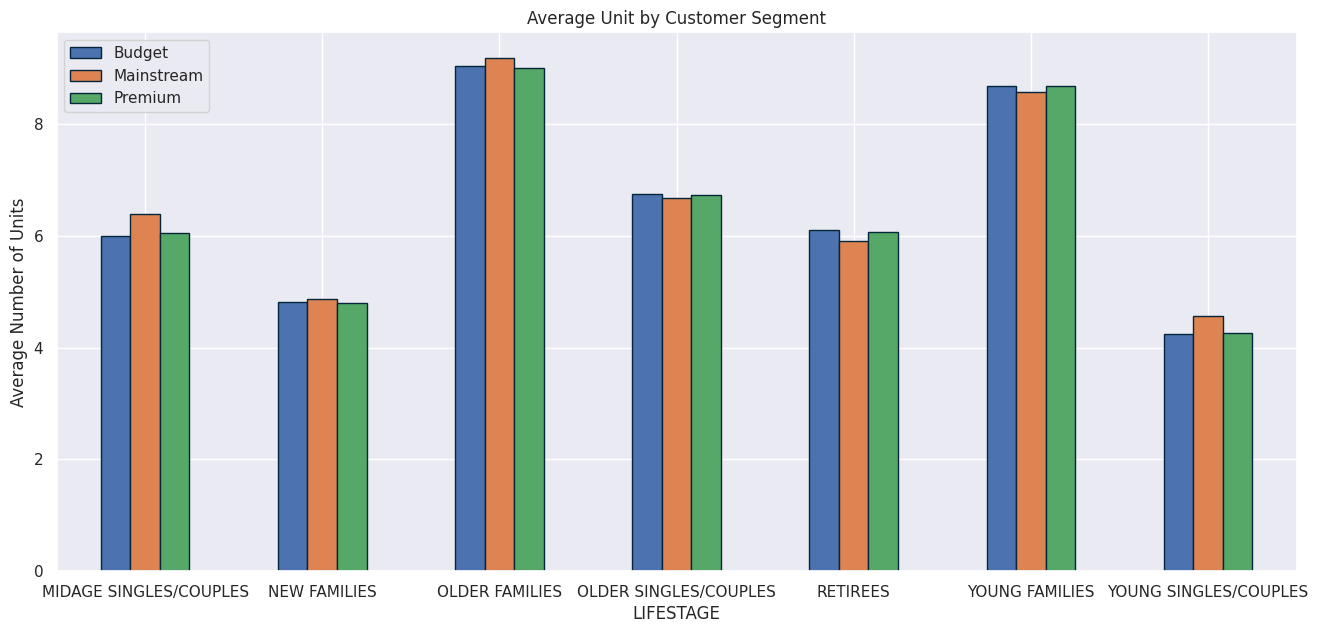

In [68]:
df10.unstack().plot(kind = 'bar', figsize = (16, 7), rot = 0, title = 'Average Unit by Customer Segment',  edgecolor="#04253a")
plt.ylabel('Average Number of Units')
plt.legend(['Budget', 'Mainstream', 'Premium'], loc = 2)

*For all the three Lifestages, Older families and Young Families buy more chips per customer.*

**4. What's the average chip price by customer segment?**

In [70]:
# Average price per unit by PREMIUM_CUSTOMER and LIFESTAGE

df11 = df4.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE']).TOT_SALES.sum() / df4.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE']).PROD_QTY.sum()
df11 = pd.DataFrame(df11, columns = ['Price per Unit'])

In [71]:
df11.sort_values(by = 'Price per Unit', ascending = False).head()

Price per Unit
PREMIUM_CUSTOMER LIFESTAGE                             
Mainstream       YOUNG SINGLES/COUPLES         4.072581
                 MIDAGE SINGLES/COUPLES        3.991821
                 NEW FAMILIES                  3.936082
Budget           RETIREES                      3.929336
                 NEW FAMILIES                  3.929336

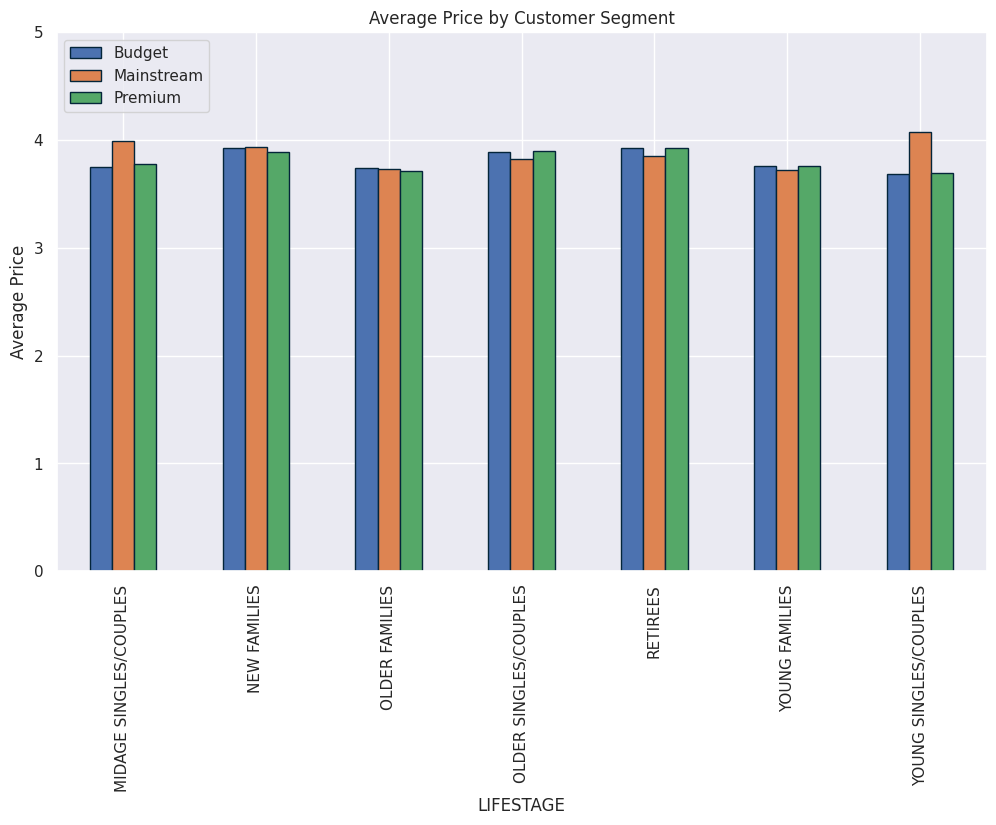

In [72]:
# Visualise

df11 = pd.DataFrame(df4.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).TOT_SALES.sum() / df4.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).PROD_QTY.sum())
df11.unstack().plot(kind = 'bar', figsize = (12, 7), title = 'Average Price by Customer Segment', ylim = (0, 5),  edgecolor="#04253a")
plt.ylabel('Average Price')
plt.legend(['Budget', 'Mainstream', 'Premium'], loc = 2)

*Mainstream midage singles/couples and young singles/couples pay more per packet of chips compared to other segments.*

In [73]:
# Perform an independent t-test between mainstream vs non-mainstream midage and young singles/couples to test this difference

# Create a new dataframe pricePerUnit
pricePerUnit = df4

# Create a new column under pricePerUnit called PRICE
pricePerUnit['PRICE'] = pricePerUnit['TOT_SALES'] / pricePerUnit['PROD_QTY']

# Let's have a look
pricePerUnit.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,pack_size,Brand Name,LIFESTAGE,PREMIUM_CUSTOMER,PRICE
0,2018-10-17,1,1000,1,5,Natural Chip Company SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium,3.00
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget,2.10
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget,1.45
3,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths,MIDAGE SINGLES/COUPLES,Budget,5.70
4,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,Grain,MIDAGE SINGLES/COUPLES,Budget,3.60


In [74]:
# Let's group our data into mainstream and non-mainstream

mainstream = pricePerUnit.loc[(pricePerUnit['PREMIUM_CUSTOMER'] == 'Mainstream') & ( (pricePerUnit['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') | (pricePerUnit['LIFESTAGE'] == 'MIDAGE SINGLES/COUPLES') ), 'PRICE']
nonMainstream = pricePerUnit.loc[(pricePerUnit['PREMIUM_CUSTOMER'] != 'Mainstream') & ( (pricePerUnit['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') | (pricePerUnit['LIFESTAGE'] == 'MIDAGE SINGLES/COUPLES') ), 'PRICE']

In [75]:
# Perform t-test

ttest_ind(mainstream, nonMainstream)

TtestResult(statistic=np.float64(37.75436700602205), pvalue=np.float64(3.994900439186394e-308), df=np.float64(57233.0))

# Let us further explore and target the segment Mainstream and young singles/couples that contributes most to the sales.


**Let's find out if they tend to buy a particular brand of chips.**

In [76]:
df4

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,pack_size,Brand Name,LIFESTAGE,PREMIUM_CUSTOMER,PRICE
0,2018-10-17,1,1000,1,5,Natural Chip Company SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium,3.00
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget,2.10
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget,1.45
3,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths,MIDAGE SINGLES/COUPLES,Budget,5.70
4,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,Grain,MIDAGE SINGLES/COUPLES,Budget,3.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
246068,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175,Kettle,YOUNG SINGLES/COUPLES,Premium,5.40
246069,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175,Tostitos,YOUNG SINGLES/COUPLES,Premium,4.40
246070,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170,Doritos,YOUNG SINGLES/COUPLES,Premium,4.40
246071,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150,Doritos,YOUNG SINGLES/COUPLES,Premium,3.90


In [77]:
dfa = df4[(df4['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (df4['PREMIUM_CUSTOMER'] == 'Mainstream')]
dfb = df4[(df4['LIFESTAGE'] != 'YOUNG SINGLES/COUPLES') & (df4['PREMIUM_CUSTOMER'] != 'Mainstream')]

In [78]:
dfa_quantity = dfa['PROD_QTY'].sum()
dfa_quantity

np.int64(36045)

In [79]:
dfb_quantity = dfb['PROD_QTY'].sum()
dfb_quantity

np.int64(261850)

In [80]:
dfa_quantity_brand = dfa.groupby(['Brand Name'])['PROD_QTY'].sum()
dfa_quantity_brand

,PROD_QTY
Brand Name,
Burger,106
CCs,405
Cheetos,291
Cheezels,651
Cobs,1609
Dorito,569
Doritos,3867
French,143
Grain,1051


In [81]:
dfb_quantity_brand = dfb.groupby(['Brand Name'])['PROD_QTY'].sum()
dfb_quantity_brand

,PROD_QTY
Brand Name,
Burger,1723
CCs,4861
Cheetos,3084
Cheezels,4926
Cobs,10085
Dorito,3379
Doritos,23079
French,1504
Grain,6505


In [82]:
# To check the brand affinity

dfa_affinity = dfa_quantity_brand/dfa_quantity
dfb_affinity = dfb_quantity_brand/dfb_quantity

affinity = (dfa_affinity/dfb_affinity).sort_values(ascending = False)

df_affinity= pd.DataFrame({'Brand Name':affinity.index, 'Affinity':affinity.values})
df_affinity

,Brand Name,Affinity
0,Tyrrells,1.234333
1,Dorito,1.223296
2,Twisties,1.223252
3,Doritos,1.217208
4,Infzns,1.194563
5,Tostitos,1.187583
6,Kettle,1.184349
7,Pringles,1.181524
8,Grain,1.173716
9,Cobs,1.159011


*Tyrell chips seems to be the most popular brand for Mainstream young singles/couples almost 23% more than the rest of the audience whereas Burger Rings were purchased less than 56% less as compared to rest of the people.*

# Let’s also find out if our target segment tends to buy larger packs of chips.

In [83]:
dfa_quantity_pack = dfa.groupby(['pack_size'])['PROD_QTY'].sum()
dfb_quantity_pack = dfb.groupby(['pack_size'])['PROD_QTY'].sum()

In [84]:
# To Check Pack Affinity
dfa_affinity_pack = dfa_quantity_pack/dfa_quantity
dfb_affinity_pack = dfb_quantity_pack/dfb_quantity

affinity_pack = (dfa_affinity_pack/dfb_affinity_pack).sort_values(ascending = False)

df_affinity_pack = pd.DataFrame({'Pack Size':affinity_pack.index, 'Affinity':affinity_pack.values})
df_affinity_pack

,Pack Size,Affinity
0,270,1.280270
1,380,1.252356
2,330,1.209843
3,110,1.186784
4,134,1.181524
5,210,1.173716
6,135,1.127513
7,250,1.112974
8,170,1.010375
9,150,0.961589


In [85]:
Product_name = df4[(df4['pack_size'] == '270')]['PROD_NAME']

Product_name.unique()

array(['Twisties Cheese     270g', 'Twisties Chicken270g'], dtype=object)

*Mainstream young singles/couples are 27% more likely to purchase a 270g pack of Twisties Cheese chips which reflects the higher volume of sales.*

In [86]:
Product_name_least = df4[(df4['pack_size'] == '220')]['PROD_NAME']

Product_name_least.unique()

array(['Burger Rings 220g'], dtype=object)

In [87]:
# Export the consolidated dataframe to a CSV file
df4.to_csv('consolidated_data.csv', index=False)

*Mainstream young singles/couples are 56% less likely to purchase a 220g pack of Burger Rings which reflects the lower volume of sales.*

# Conclusion

* Budget – older families, Mainstream – young singles/couples, and Mainstream – retirees shoppers have accounted for the majority of sales.
* Mainstream young singles/couples and retirees spend more money on chips than other purchasers mainly due to the fact that there are more customers in these segments.
* Additionally, young, middle-aged, and mainstream individuals and couples are more inclined to pay more for each bag of chips.
* They are also 23% more likely to purchase 'Tyrrells' and '270g' pack sizes than the rest of the population.